In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw6_exercise_1.ipynb")

# CPSC 330 - Applied Machine Learning 

## Homework 6: Clustering (Exercise 1)
### Associated lectures: [Lectures 14 and 15](https://ubc-cs.github.io/cpsc330-2026S1/#lecture-schedule-tentative)

**Due date: See [deliverable due dates](https://ubc-cs.github.io/cpsc330-2026S1/#deliverable-due-dates-tentative)**.

## Imports <a name="im"></a>

In [2]:
import os
from hashlib import sha1

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline
pd.set_option("display.max_colwidth", 0)

<br><br><br><br>

<!-- BEGIN QUESTION -->

<div class="alert alert-info">
    
## Instructions
rubric={points}

You will earn points for following these instructions and successfully submitting your work in PrairieLearn.

### Group work instructions

**You may work with a partner on this homework and submit your assignment as a group.** Below are some instructions on working as a group.
- The maximum group size is 2.
- Use group work as an opportunity to collaborate and learn new things from each other.
- Be respectful to each other and make sure you understand all the concepts in the assignment well.
- It is your responsibility to make sure your PrairieLearn group is set up correctly and that the assignment is submitted before the deadline.

### General submission instructions

- Please **read carefully [Use of Generative AI policy](https://ubc-cs.github.io/cpsc330-2026S1/syllabus#use-of-generative-ai-in-the-course)** before starting the homework assignment.
- **Run all cells before submitting:** Go to `Kernel -> Restart Kernel and Clear All Outputs`, then select `Run -> Run All Cells`. This ensures your notebook runs cleanly from start to finish without errors.
- **Save your work in JupyterLab:** Make sure `hw6_exercise_1.ipynb` is saved.
- **Check your saved submission in PrairieLearn:** Return to the PrairieLearn question page and click **Save only** to capture your notebook and review the preview. When you are ready to submit for grading, click **Save & Grade**.
- **Check that outputs render properly:** Make sure all plots and outputs appear in the notebook preview.
- **Keep execution order clean:** Execution numbers should start at "1" and increase in order. Out-of-order or missing execution numbers may result in mark deductions.
- **Follow course submission guidelines:** Review the [CPSC 330 homework instructions](https://ubc-cs.github.io/cpsc330-2026S1/docs/homework-instructions/) for detailed guidance on completing and submitting assignments.

</div>

<!-- END QUESTION -->

<br><br><br><br>

## Exercise 1: Document clustering warm-up
<hr>

In this homework, we will explore a popular application of clustering called [**document clustering**](https://en.wikipedia.org/wiki/Document_clustering). A large amount of unlabeled text data is available out there (e.g., news, recipes, online Q&A, tweets), and clustering is a commonly used technique to organize this data in a meaningful way. 

As a warm up, in this exercise you will cluster sentences from a toy corpus. Later in the homework you will work with a real corpus. 

The code below extracts introductory sentences of Wikipedia articles on a set of queries. To run the code successfully, you will need the `wikipedia` package installed in the course environment. 

```
conda activate cpsc330
conda install -c conda-forge wikipedia
```


**Your tasks:**

Run the code below which 
- extracts content of Wikipedia articles on a set of queries
- tokenizes the text (i.e., separates sentences) and 
- stores the 2nd sentence in each article as a document representing that article

> Feel free to experiment with Wikipedia queries of your choice. But stick to the provided list for the final submission so that it's easier for the TAs to grade your submission.

> For tokenization we are using the `nltk` package. If you do not have this package in the course environment, you will have to install it.

```
conda activate cpsc330
conda install -c anaconda nltk
```

Even if you have the package installed via the course `conda` environment, you might have to download `nltk` pre-trained models, which can be done with the code below.

In [3]:
import nltk

nltk.download("punkt")
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ananr\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ananr\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [4]:
import wikipedia
import string
from nltk.tokenize import sent_tokenize, word_tokenize

queries = [
    "Artificial Intelligence",
    "Deep learning",
    "Unsupervised learning",
    "Quantum Computer",
    "Environmental protection",
    "Climate Change",
    "Green energy",
    "Biodiversity",
    "French Cuisine",
    "Bread food",
    "Dumpling food",
]
wiki_dict = {"wiki query": [], "text": [], "n_words": []}
remove_tokens = list(string.punctuation) + ['``', '’', '`', 'br', '"', "”", "''", "'s", "(", ")", "[", "]"]

# Running this code might take some time.
for query in queries:
    try:
        # Attempt to fetch the page content
        page_content = wikipedia.page(query).content
    except wikipedia.exceptions.PageError:
        print(f"Page not found for query: {query}. Skipping...")
        continue
    except wikipedia.exceptions.DisambiguationError as e:
        print(f"Query: {query} led to a disambiguation page. Choosing the first option: {e.options[0]}")
        page_content = wikipedia.page(e.options[0]).content

    text = sent_tokenize(page_content)[0]
    tokenized = word_tokenize(text)
    text_pp = [token.lower() for token in tokenized if token.lower() not in remove_tokens]
    wiki_dict["n_words"].append(len(text_pp))
    wiki_dict["text"].append(" ".join(text_pp))
    wiki_dict["wiki query"].append(query)

wiki_df = pd.DataFrame(wiki_dict)
wiki_df

,wiki query,text,n_words
0,Artificial Intelligence,artificial intelligence ai is the capability of computational systems to perform tasks typically associated with human intelligence such as learning reasoning problem-solving perception and decision-making,25
1,Deep learning,in machine learning deep learning dl focuses on utilizing multilayered neural networks to perform tasks such as classification regression and representation learning,22
2,Unsupervised learning,in machine learning supervised learning sl is a type of machine learning paradigm where an algorithm learns to map input data to a specific output based on example input-output pairs,30
3,Quantum Computer,a quantum computer is a real or theoretical computer that exploits quantum phenomena like superposition and entanglement in an essential way,21
4,Environmental protection,environmental protection or environment protection refers to the taking of measures to protecting the natural environment prevent pollution and maintain ecological balance,22
5,Climate Change,present-day climate change includes both global warming — the ongoing increase in global average temperature — and its wider effects on earth climate system,24
6,Green energy,energy is sustainable if it meets the needs of the present without compromising the ability of future generations to meet their own needs,23
7,Biodiversity,biodiversity is the variability of life on earth,8
8,French Cuisine,french cuisine is the cooking traditions and practices of france,10
9,Bread food,bread is a baked food product made from water flour and often yeast,13


Our toy corpus has six toy documents (`text` column in the dataframe) extracted from Wikipedia queries. 

<br><br>

<!-- BEGIN QUESTION -->

### 1.1 How many clusters? 
rubric={reasoning}

<div class="alert alert-info">

**Your tasks:**

- If tasked with manually clustering documents from this toy corpus, how many clusters would you identify, and what labels would you assign to each cluster?
</div>

<div class="alert alert-warning">

Solution_1.1
    
</div>

_Points:_ 1

If I were  to manually cluster these documents, I would identify three main clusters: Technology/ML, Environment, Food & Culinary. 

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

### 1.2 K-Means with bag-of-words representation 
rubric={accuracy}

In the lecture, we explored how **data representation significantly impacts clustering quality**. We saw that replacing a **flattened image representation** with feature vectors extracted from **pre-trained models** greatly improved clustering results.  

What about text data? In previous machine learning courses, we have used the **bag-of-words (BoW) representation** to numerically encode text, where each document is represented with a vector of word frequencies. 

In this exercise, you will **cluster documents** using this **simplistic text representation**.  

<div class="alert alert-info">

**Your tasks:**

1. Use [`CountVectorizer`](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) with its **default settings** to transform the `text` column in `wiki_df` into a numerical representation.  

2. Use [`KMeans`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) to cluster the encoded documents and store the cluster labels in `kmeans_bow_labels`.  
   - Set `random_state=42` for **reproducibility**.
     
   - Use the **number of clusters** (`n_clusters`) identified in the **previous exercise**.  
</div>

<div class="alert alert-warning">

Solution_1.2
    
</div>

_Points:_ 2

In [6]:
from sklearn.feature_extraction.text import CountVectorizer

vec = CountVectorizer()
X_bow = vec.fit_transform(wiki_df["text"])

In [9]:
from sklearn.cluster import KMeans
kmeans_bow = KMeans(n_clusters = 3, random_state = 42)
kmeans_bow_labels = kmeans_bow.fit_predict(X_bow)

In [10]:
wiki_df["bow_kmeans"] = kmeans_bow_labels
wiki_df

,wiki query,text,n_words,bow_kmeans
0,Artificial Intelligence,artificial intelligence ai is the capability of computational systems to perform tasks typically associated with human intelligence such as learning reasoning problem-solving perception and decision-making,25,1
1,Deep learning,in machine learning deep learning dl focuses on utilizing multilayered neural networks to perform tasks such as classification regression and representation learning,22,2
2,Unsupervised learning,in machine learning supervised learning sl is a type of machine learning paradigm where an algorithm learns to map input data to a specific output based on example input-output pairs,30,2
3,Quantum Computer,a quantum computer is a real or theoretical computer that exploits quantum phenomena like superposition and entanglement in an essential way,21,1
4,Environmental protection,environmental protection or environment protection refers to the taking of measures to protecting the natural environment prevent pollution and maintain ecological balance,22,0
5,Climate Change,present-day climate change includes both global warming — the ongoing increase in global average temperature — and its wider effects on earth climate system,24,1
6,Green energy,energy is sustainable if it meets the needs of the present without compromising the ability of future generations to meet their own needs,23,1
7,Biodiversity,biodiversity is the variability of life on earth,8,1
8,French Cuisine,french cuisine is the cooking traditions and practices of france,10,1
9,Bread food,bread is a baked food product made from water flour and often yeast,13,1


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

### 1.3 K-Means with sentence embedding representation
rubric={accuracy}

In the previous exercise, you may have noticed that clustering results were suboptimal. While the bag-of-words (BoW) representation is useful, it has significant limitations. It does not capture word order or context effectively.  

To improve text representation, we can use pre-trained models, similar to those used for image data, to extract richer, context-aware embeddings through transfer learning. In this lab, we will use the **pre-trained model** `'all-MiniLM-L6-v2'`, available via the [Sentence Transformers](https://www.sbert.net/index.html) package.  

This deep learning model generates **dense, fixed-length vector representations** of sentences, capturing **semantic meaning and contextual information**. These representations are particularly effective for **clustering and semantic similarity tasks**. If you're interested in exploring more **pre-trained models**, refer to the [full list here](https://www.sbert.net/docs/pretrained_models.html). We will explore these representations further in **DSCI 575**.  

<div class="alert alert-info">

**Your tasks:**

1. Run the code below to create sentence embedding representation of documents in our toy corpus.
   
3. Apply `KMeans` to the **sentence embeddings** (`emb_sents`) and store the cluster labels in `kmeans_emb_labels`. Use the following parameters:  
    - `random_state=42` (for reproducibility)
      
    - `n_clusters`=the number of clusters you identified in 1.1

Note
- The code below might throw a warning. You may ignore it for the purpose of this lab. 
</div>

In [12]:
from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer("all-MiniLM-L6-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

c:\Users\ananr\anaconda3\envs\machine_learning\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ananr\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [13]:
emb_sents = embedder.encode(wiki_df["text"].tolist())
emb_sent_df = pd.DataFrame(emb_sents, index=wiki_df.index)
emb_sent_df

,0,1,2,3,4,5,6,7,8,9,...,374,375,376,377,378,379,380,381,382,383
0,-0.005857,-0.004795,-0.000976,0.011121,0.005294,-0.061630,0.062072,0.033673,-0.035251,0.074071,...,0.088312,-0.006600,0.036511,-0.020797,-0.002082,0.058263,0.061880,0.097383,0.058155,-0.052016
1,-0.122905,-0.092450,0.085379,-0.009761,0.001422,0.069146,-0.046654,-0.069960,-0.021858,-0.052803,...,0.065826,0.031800,-0.021052,-0.113772,-0.013588,0.056793,-0.013167,0.009044,-0.011912,-0.011387
2,-0.056721,-0.049697,-0.014780,0.022572,0.051773,0.007456,0.008632,-0.074847,-0.065573,-0.027284,...,0.014761,-0.022392,0.021360,-0.107016,0.020530,0.045678,0.052755,0.005429,0.022018,-0.010994
3,-0.068892,0.010519,-0.064375,0.028483,-0.128162,0.022584,-0.053411,-0.038302,-0.023511,0.021045,...,-0.076978,-0.007454,-0.040548,-0.057332,-0.015641,0.123058,0.046373,0.074645,0.063804,0.053124
4,-0.012700,0.101830,0.066676,-0.007987,0.140040,0.041627,0.035495,-0.050723,-0.037632,0.055886,...,-0.042105,-0.038883,0.018268,0.009920,0.028208,0.052759,-0.009605,-0.004518,0.060853,0.057709
5,-0.014444,0.022869,0.145982,0.054865,0.085204,-0.014689,-0.102757,0.016853,-0.023799,0.021148,...,0.011778,0.016817,-0.020041,0.006375,0.055428,0.076868,-0.047152,-0.114797,-0.056382,0.022349
6,-0.031736,0.118141,-0.018028,0.030316,0.024178,0.016458,-0.050963,-0.042919,-0.026772,0.006739,...,-0.059070,0.019544,-0.042921,0.057469,-0.041383,0.009132,0.135324,0.012424,0.021720,0.058171
7,0.027806,0.077117,0.015402,-0.013544,0.043216,0.048124,0.027763,-0.022999,0.049303,0.009686,...,0.014946,-0.020896,0.022283,-0.012311,0.014079,0.028085,0.025272,-0.015233,-0.014879,-0.064280
8,0.026616,-0.019929,-0.008049,-0.025907,-0.055372,0.011235,-0.024538,-0.065724,0.058374,-0.062895,...,-0.059513,0.077446,-0.059827,-0.021454,0.088102,-0.127180,-0.031399,0.120572,0.072373,-0.058336
9,-0.014786,0.055887,-0.020880,0.005313,-0.025037,0.040479,0.035260,0.024938,0.017546,0.072433,...,-0.082098,0.037856,-0.020007,-0.087252,0.058163,-0.044187,-0.030253,-0.080385,0.075614,-0.070403


<div class="alert alert-warning">

Solution_1.3
    
</div>

_Points:_ 2

In [16]:
kmeans_emb = KMeans(n_clusters = 3, random_state = 42)

In [17]:
kmeans_emb_labels = kmeans_emb.fit_predict(emb_sents)

c:\Users\ananr\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [18]:
wiki_df["emb_kmeans"] = kmeans_emb_labels
wiki_df

,wiki query,text,n_words,bow_kmeans,emb_kmeans
0,Artificial Intelligence,artificial intelligence ai is the capability of computational systems to perform tasks typically associated with human intelligence such as learning reasoning problem-solving perception and decision-making,25,1,2
1,Deep learning,in machine learning deep learning dl focuses on utilizing multilayered neural networks to perform tasks such as classification regression and representation learning,22,2,2
2,Unsupervised learning,in machine learning supervised learning sl is a type of machine learning paradigm where an algorithm learns to map input data to a specific output based on example input-output pairs,30,2,2
3,Quantum Computer,a quantum computer is a real or theoretical computer that exploits quantum phenomena like superposition and entanglement in an essential way,21,1,2
4,Environmental protection,environmental protection or environment protection refers to the taking of measures to protecting the natural environment prevent pollution and maintain ecological balance,22,0,0
5,Climate Change,present-day climate change includes both global warming — the ongoing increase in global average temperature — and its wider effects on earth climate system,24,1,0
6,Green energy,energy is sustainable if it meets the needs of the present without compromising the ability of future generations to meet their own needs,23,1,0
7,Biodiversity,biodiversity is the variability of life on earth,8,1,0
8,French Cuisine,french cuisine is the cooking traditions and practices of france,10,1,1
9,Bread food,bread is a baked food product made from water flour and often yeast,13,1,1


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

### 1.4 DBSCAN with sentence embedding representation and cosine distance  
rubric={accuracy}

Now, let's apply [`DBSCAN`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html) to our toy dataset.  

Unlike K-Means, which relies on Euclidean distance due to its use of centroids, DBSCAN allows us to experiment with different distance metrics. For text data, [**cosine similarity**](https://scikit-learn.org/stable/modules/metrics.html#cosine-similarity) (or its complement, **cosine distance**) is often more effective than Euclidean distance.  

The **cosine distance** between two vectors $u$ and $v$ is defined as: 

$$distance_{cosine}(u,v) = 1 - (\frac{u \cdot v}{\left\lVert u\right\rVert_2 \left\lVert v\right\rVert_2})$$

<div class="alert alert-info">

**Your tasks:**

- Apply **DBSCAN** to cluster documents encoded with **sentence embeddings** (`emb_sents`) and store the cluster labels in `dbscan_emb_labels`.
    
- Set `metric='cosine'` to use **cosine distance** for clustering.
- Tune the **hyperparameters** `eps` and `min_samples` to obtain meaningful clusters, as the default values are unlikely to work well on this dataset.  

**Notes for tuning the hyperparameters:**

- Start by examining the minimum, maximum, and mean cosine distances in the dataset. You can compute pairwise cosine distances using the package imported below.
  
- Experiment with a range of `eps` values and print the number of clusters and their sizes for each value.
- Select the `eps` value that produces the desired number of clusters.


</div>

In [19]:
from sklearn.metrics.pairwise import cosine_distances

<div class="alert alert-warning">

Solution_1.4
    
</div>

_Points:_ 4

In [22]:
#compute pairwise cosine distance
pairwise_dist = cosine_distances(emb_sents)


In [23]:
#get upper triangle so prevent skewing of calcs
upper_tri = pairwise_dist[np.triu_indices_from(pairwise_dist, k=1)]
print("max:")
print(f"{upper_tri.max():.4f}")
print("min:")
print(f"{upper_tri.min():.4f}")
print("mean:")
print(f"{upper_tri.mean():.4f}")


max:
1.0375
min:
0.5178
mean:
0.8985


In [24]:
from sklearn.cluster import DBSCAN
eps_range = [0.55, 0.6, 0.65, 0.7, 0.75, 0.8]
min_samples_range = [2,3,4]

for min_samples in min_samples_range:
    for eps in eps_range:
        db = DBSCAN(eps=eps, min_samples=min_samples, metric='cosine')
        labels = db.fit_predict(emb_sents)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        print(f"eps: {eps}, min_samples: {min_samples} => n_clusters: {n_clusters}, n_noise: {n_noise}")

eps: 0.55, min_samples: 2 => n_clusters: 1, n_noise: 9
eps: 0.6, min_samples: 2 => n_clusters: 1, n_noise: 8
eps: 0.65, min_samples: 2 => n_clusters: 2, n_noise: 5
eps: 0.7, min_samples: 2 => n_clusters: 2, n_noise: 4
eps: 0.75, min_samples: 2 => n_clusters: 3, n_noise: 0
eps: 0.8, min_samples: 2 => n_clusters: 3, n_noise: 0
eps: 0.55, min_samples: 3 => n_clusters: 0, n_noise: 11
eps: 0.6, min_samples: 3 => n_clusters: 1, n_noise: 8
eps: 0.65, min_samples: 3 => n_clusters: 1, n_noise: 7
eps: 0.7, min_samples: 3 => n_clusters: 2, n_noise: 4
eps: 0.75, min_samples: 3 => n_clusters: 3, n_noise: 0
eps: 0.8, min_samples: 3 => n_clusters: 3, n_noise: 0
eps: 0.55, min_samples: 4 => n_clusters: 0, n_noise: 11
eps: 0.6, min_samples: 4 => n_clusters: 0, n_noise: 11
eps: 0.65, min_samples: 4 => n_clusters: 1, n_noise: 7
eps: 0.7, min_samples: 4 => n_clusters: 1, n_noise: 7
eps: 0.75, min_samples: 4 => n_clusters: 2, n_noise: 3
eps: 0.8, min_samples: 4 => n_clusters: 2, n_noise: 3


In [26]:
#we have chosen eps = 0.75, min_samples = 3
dbscan_final = DBSCAN(eps=0.75, min_samples=3, metric='cosine')

In [27]:
dbscan_emb_labels = dbscan_final.fit_predict(emb_sents)

In [28]:
wiki_df["emb_dbscan"] = dbscan_emb_labels
wiki_df

,wiki query,text,n_words,bow_kmeans,emb_kmeans,emb_dbscan
0,Artificial Intelligence,artificial intelligence ai is the capability of computational systems to perform tasks typically associated with human intelligence such as learning reasoning problem-solving perception and decision-making,25,1,2,0
1,Deep learning,in machine learning deep learning dl focuses on utilizing multilayered neural networks to perform tasks such as classification regression and representation learning,22,2,2,0
2,Unsupervised learning,in machine learning supervised learning sl is a type of machine learning paradigm where an algorithm learns to map input data to a specific output based on example input-output pairs,30,2,2,0
3,Quantum Computer,a quantum computer is a real or theoretical computer that exploits quantum phenomena like superposition and entanglement in an essential way,21,1,2,0
4,Environmental protection,environmental protection or environment protection refers to the taking of measures to protecting the natural environment prevent pollution and maintain ecological balance,22,0,0,1
5,Climate Change,present-day climate change includes both global warming — the ongoing increase in global average temperature — and its wider effects on earth climate system,24,1,0,1
6,Green energy,energy is sustainable if it meets the needs of the present without compromising the ability of future generations to meet their own needs,23,1,0,1
7,Biodiversity,biodiversity is the variability of life on earth,8,1,0,1
8,French Cuisine,french cuisine is the cooking traditions and practices of france,10,1,1,2
9,Bread food,bread is a baked food product made from water flour and often yeast,13,1,1,2


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

### 1.5 Hierarchical clustering with sentence embedding representation
rubric={accuracy}

<div class="alert alert-info">

**Your tasks:**

Apply hierarchical clustering on `emb_sents`. In particular
1. Create and show a dendrogram with `complete` linkage and `metric='cosine'` on this toy dataset.

3. Create flat clusters using `fcluster` with appropriate hyperparameters and store cluster labels to `hier_emb_labels` variable below.

</div>

<div class="alert alert-warning">

Solution_1.5
    
</div>

_Points:_ 3

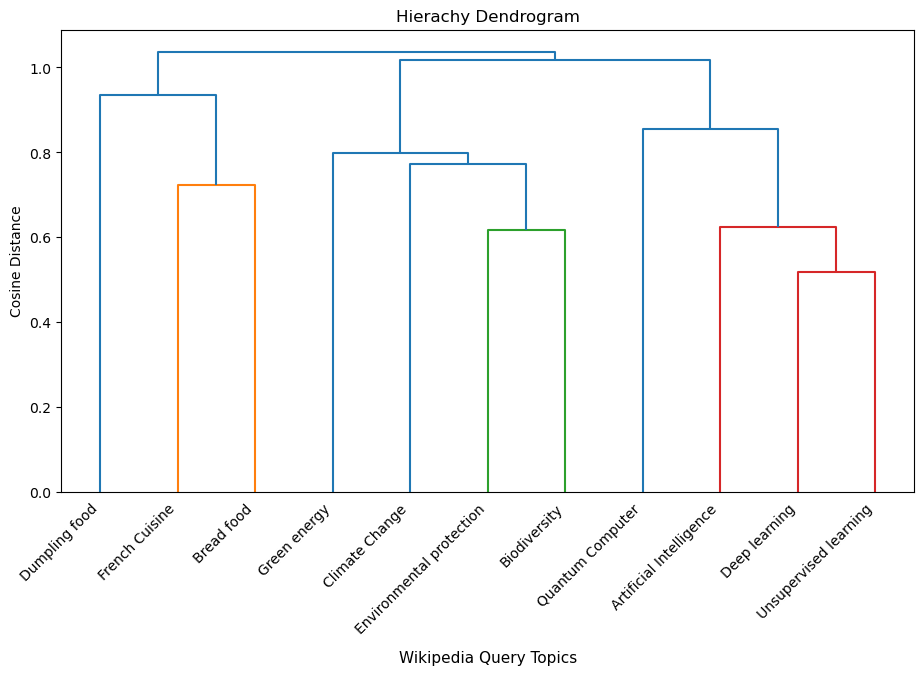

In [43]:
import matplotlib.pyplot as plt # Re-imports and fixes the overwritten 'plt' variable
from scipy.cluster.hierarchy import dendrogram, linkage

hierachy_linkage = linkage(emb_sents, method='complete', metric='cosine')

fig, ax = plt.subplots(figsize=(11, 6))
dendrogram(hierachy_linkage, labels=wiki_df["wiki query"].tolist(), leaf_font_size = 10, orientation = 'top', ax=ax)
plt.title("Hierachy Dendrogram")
plt.ylabel("Cosine Distance")
plt.xlabel("Wikipedia Query Topics", fontsize=11, labelpad=10)
plt.xticks(rotation=45, ha='right')
plt.show()

In [45]:
from scipy.cluster.hierarchy import fcluster
hier_emb_labels = fcluster(hierachy_linkage, t=3, criterion='maxclust')

In [46]:
wiki_df["emb_hierarchical"] = hier_emb_labels
wiki_df

,wiki query,text,n_words,bow_kmeans,emb_kmeans,emb_dbscan,emb_hierarchical
0,Artificial Intelligence,artificial intelligence ai is the capability of computational systems to perform tasks typically associated with human intelligence such as learning reasoning problem-solving perception and decision-making,25,1,2,0,3
1,Deep learning,in machine learning deep learning dl focuses on utilizing multilayered neural networks to perform tasks such as classification regression and representation learning,22,2,2,0,3
2,Unsupervised learning,in machine learning supervised learning sl is a type of machine learning paradigm where an algorithm learns to map input data to a specific output based on example input-output pairs,30,2,2,0,3
3,Quantum Computer,a quantum computer is a real or theoretical computer that exploits quantum phenomena like superposition and entanglement in an essential way,21,1,2,0,3
4,Environmental protection,environmental protection or environment protection refers to the taking of measures to protecting the natural environment prevent pollution and maintain ecological balance,22,0,0,1,2
5,Climate Change,present-day climate change includes both global warming — the ongoing increase in global average temperature — and its wider effects on earth climate system,24,1,0,1,2
6,Green energy,energy is sustainable if it meets the needs of the present without compromising the ability of future generations to meet their own needs,23,1,0,1,2
7,Biodiversity,biodiversity is the variability of life on earth,8,1,0,1,2
8,French Cuisine,french cuisine is the cooking traditions and practices of france,10,1,1,2,1
9,Bread food,bread is a baked food product made from water flour and often yeast,13,1,1,2,1


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

### 1.6 Discussion
rubric={reasoning}

<div class="alert alert-info">

**Your tasks:**

Reflect on and discuss the clustering results of the methods you explored in the previous exercises, focusing on the following points:    
- effect of input representation on clustering results

- whether the clustering results match with your intuitions and the challenges associated with getting the desired clustering results with each method

</div>

<div class="alert alert-warning">

Solution_1.6
    
</div>

_Points:_ 4

When analyzing my clustering results, I found that the choice of input representation had a drastically larger impact on the final clusters than the choice of the clustering algorithms themselves. Using the Bag-of-Words (BoW) representation with K-Means yielded very poor results because it relies entirely on exact token frequency matches. Because BoW lacks semantic understanding, it completely missed the conceptual connections between topics, mistakenly grouping unrelated queries like Quantum Computer, Climate Change, and French Cuisine together simply because they didn't share specific vocabulary. In stark contrast, switching to dense sentence embeddings (all-MiniLM-L6-v2) completely transformed the performance across K-Means, DBSCAN, and Hierarchical clustering. Because embeddings capture semantic context and meaning rather than raw words, all three embedding-based methods were able to recognize thematic similarities, resulting in clean, logical groupings.These embedding-based clustering results perfectly matched my human intuition, successfully partitioning the 11 Wikipedia queries into the 3 distinct thematic groups I expected: Technology, Environment, and Food. However, achieving this intuitive clustering came with distinct challenges for each method. With K-Means, the primary challenge was that I had to manually specify the correct number of clusters ($k=3$) upfront, meaning the algorithm cannot discover the natural structure of the data on its own. For DBSCAN, the challenge shifted to intense hyperparameter tuning; because high-dimensional embeddings sit at a relatively high baseline distance, setting the radius (eps) too low resulted in almost all documents being discarded as noise points, requiring careful calibration to find the sweet spot where clusters formed without noise. Finally, for Hierarchical clustering, the main challenge was selecting the appropriate linkage criterion (such as complete linkage) and determining the exact tree-cut threshold to extract the flat clusters cleanly.

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

### 1.7 Visualizing clusters
rubric={points:4}


One approach to working with unlabeled data is visualization. That said, our data is high-dimensional, making it challenging to visualize. Take sentence embedding representation as an example: each instance is depicted in 768 dimensions. To visualize such high-dimensional data, we can employ dimensionality reduction techniques to extract the most significant 2 or 3 components, and then visualize this low-dimensional data.

Given data as a `numpy` array and corresponding cluster assignments, the `plot_umap_clusters` function below transforms the data by applying dimensionality reduction technique called [UMAP](https://umap-learn.readthedocs.io/en/latest/) to it and plots the transformed data with different colours for different clusters. 

> *Note: At this point we are using this function only for visualization and you are not expected to understand the UMAP part.* 

You'll have to install the `umap-learn` package in the course conda environment either with `conda` or `pip`, as described in the [documentation](https://umap-learn.readthedocs.io/en/latest/index.html). 

```
> conda activate cpsc330
> conda install -c conda-forge umap-learn
```
or

```
> conda activate cpsc330
> pip install umap-learn 
```

If you get an error with the import below try

```
pip install --upgrade numba umap-learn
```

<div class="alert alert-info">
    
**Your tasks:**

1. Visualize the clusters created by the methods above using `plot_umap_clusters` function below. In other words, visualize clusters identified by each of the methods below. 
    - K-Means with bag-of-words representation 
    - K-Means with sentence embedding representation
    - DBSCAN with sentence embedding representation 
    - Flat cluster of hierarchical clustering with sentence embedding representation
</div>

In [47]:
import umap

ModuleNotFoundError: No module named 'umap'

In [ ]:
def plot_umap_clusters(
    data,
    cluster_labels,
    raw_texts=None,
    show_labels=False,
    point_size=50,
    n_neighbors=15,
    title="UMAP Visualization",
    ignore_noise=False,
):
    """
    Perform dimensionality reduction using UMAP and visualize the resulting clusters.

    Parameters
    ----------
    data : np.ndarray
        Feature matrix to be reduced.
    cluster_labels : array-like
        Cluster label for each data point.
    raw_texts : list of str, optional
        Original texts corresponding to the data points (used when show_labels=True).
    show_labels : bool, default=False
        Whether to annotate points with text labels.
    point_size : int, default=50
        Size of the scatterplot points.
    n_neighbors : int, default=15
        Number of neighbors used in UMAP.
    title : str, default="UMAP Visualization"
        Title of the plot.
    ignore_noise : bool, default=False
        Whether to exclude points labeled as noise (-1).

    Returns
    -------
    None
    """
    reducer = umap.UMAP(n_neighbors=n_neighbors, random_state=42)
    embedding = reducer.fit_transform(data)

    df = pd.DataFrame(embedding, columns=["dim1", "dim2"])
    df["cluster"] = cluster_labels

    if ignore_noise:
        df = df[df["cluster"] != -1]

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.set_title(title)

    scatter = ax.scatter(
        df["dim1"], df["dim2"],
        c=df["cluster"], cmap="tab20b", s=point_size
    )

    ax.legend(*scatter.legend_elements(), title="Clusters", loc="best")

    if show_labels and raw_texts is not None:
        for (x, y, text) in zip(df["dim1"], df["dim2"], raw_texts):
            ax.annotate(" ".join(text.split()[:10]), (x, y), fontsize=8)

    plt.show()


<div class="alert alert-warning">

Solution_1.7
    
</div>

_Points:_ 4

In [ ]:
...

<!-- END QUESTION -->

<br><br><br><br>

Before submitting your assignment, please make sure you have followed all the instructions in the Submission Instructions section at the top.

Here is a quick checklist before submitting:

- [ ] Restart kernel, clear outputs, and run all cells from top to bottom.
- [ ] `.ipynb` file runs without errors and contains all outputs.
- [ ] Return to the PrairieLearn question page and click **Save only** to check the rendered notebook preview.
- [ ] When the preview looks correct, click **Save & Grade**.
- [ ] If you are working in a group, confirm your PrairieLearn group membership is correct.
- [ ] Execution numbers start at **1** and are in order.
- [ ] Review the [CPSC 330 homework instructions](https://ubc-cs.github.io/cpsc330-2026S1/docs/homework-instructions/) for details on the grading process.

![](img/eva-well-done.png)